<a href="https://colab.research.google.com/github/DJAYI/machine-learning-algorithms/blob/master/machine_learning_algorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Algoritmos de Machine Learning

In [1]:
# Importar dependencias

import pandas as pd # Pandas (Estadística)
import numpy as np # NumPy (Cuantitividad)
import matplotlib.pyplot as plt # MatPlot Lib (Gráficas)
import seaborn as sns # Apoto MatPlot Lib

from sklearn.linear_model import LinearRegression, LogisticRegression # Algoritmos de regresión
from sklearn.model_selection import train_test_split # Modelo de entrenamiento de modelo
from sklearn.metrics import r2_score, mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report # Métricas de socore en modelos
from sklearn.preprocessing import StandardScaler

In [2]:
# Configurar estilos de gráfica

%matplotlib inline
sns.set_style('whitegrid')

In [3]:
# Cargar dataset
df = pd.read_csv('intermediate_coreml_assignment_dataset.csv')
df.head()

,customer_id,age,tenure_months,income,credit_score,monthly_charges,support_tickets,avg_session_time,late_payments,gender,city_tier,plan_type,payment_method,device_type,has_international,is_student,target_reg,churn
0,200001,51,6,23039.19,718.0,1065.30,0,28.36,0,Female,Tier1,Basic,UPI,Android,No,No,44030.77,0
1,200002,46,116,54173.02,491.0,1035.67,1,15.75,0,Male,Tier2,Basic,Card,Android,No,No,138673.42,0
2,200003,20,112,37130.61,623.0,897.50,1,15.15,0,Female,Tier1,Standard,Card,Android,No,No,159250.49,0
3,200004,18,53,39873.95,850.0,1095.42,3,26.83,0,Male,Tier1,Standard,UPI,Android,No,No,109410.17,1
4,200005,22,60,39591.09,779.0,1422.29,0,18.83,0,Male,Tier2,Premium,Card,Android,No,No,91008.23,0


#### Explorar la estructura del Dataset

-  `df.shape()`: Nos dice cuantas filas y columnas tiene el dataset

- `df.info()`: Muestra los tipos de datos y cuandos valores NO NULOS hay en cada columna

- `df.describe()`: Muestra las estadísticas básicas (media, mediana, mínimo, máximo) de las columnas numéricas.

In [4]:
print(f"Forma del datase (filas & columnas): {df.shape}")

print("\n Información general \n")
df.info()

print("Estadísticas descriptivas")
df.describe()

Forma del datase (filas & columnas): (50000, 18)

 Información general 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        50000 non-null  int64  
 1   age                50000 non-null  int64  
 2   tenure_months      50000 non-null  int64  
 3   income             49305 non-null  float64
 4   credit_score       49183 non-null  float64
 5   monthly_charges    49171 non-null  float64
 6   support_tickets    50000 non-null  int64  
 7   avg_session_time   50000 non-null  float64
 8   late_payments      50000 non-null  int64  
 9   gender             49200 non-null  object 
 10  city_tier          50000 non-null  object 
 11  plan_type          50000 non-null  object 
 12  payment_method     49187 non-null  object 
 13  device_type        50000 non-null  object 
 14  has_international  50000 non-null  object 
 1

,customer_id,age,tenure_months,income,credit_score,monthly_charges,support_tickets,avg_session_time,late_payments,target_reg,churn
count,50000.000000,50000.000000,50000.000000,49305.000000,49183.000000,49171.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000
mean,225000.500000,41.216260,59.212880,44802.597299,570.410691,1196.449165,1.183460,18.018672,0.257940,100797.266424,0.10146
std,14433.901067,13.818791,34.976033,14951.337403,159.033340,452.227406,1.094361,6.052666,0.512028,30929.994410,0.30194
min,200001.000000,18.000000,0.000000,8000.000000,301.000000,200.000000,0.000000,2.000000,0.000000,34162.200000,0.00000
25%,212500.750000,29.000000,30.000000,34744.270000,436.000000,887.335000,0.000000,13.880000,0.000000,75384.930000,0.00000
50%,225000.500000,41.000000,59.000000,44688.010000,568.000000,1193.130000,1.000000,18.090000,0.000000,100444.030000,0.00000
75%,237500.250000,53.000000,89.000000,54330.260000,704.000000,1509.640000,2.000000,22.200000,0.000000,125777.310000,0.00000
max,250000.000000,65.000000,120.000000,92535.910000,850.000000,2595.860000,5.000000,36.530000,3.000000,170630.470000,1.00000


#### Limpieza del Dataset

In [5]:

print(f"""
Valores faltantes por columna (nulos):
{df.isnull().sum()}
""")


Valores faltantes por columna (nulos):
customer_id            0
age                    0
tenure_months          0
income               695
credit_score         817
monthly_charges      829
support_tickets        0
avg_session_time       0
late_payments          0
gender               800
city_tier              0
plan_type              0
payment_method       813
device_type            0
has_international      0
is_student             0
target_reg             0
churn                  0
dtype: int64



- `df.isnull().sum()`: Cuenta cuantos valores nulos hay en cada columna, Este dataset tiene valores faltantes de income, credit_score, monthly_charges, gender, payment_method.

In [6]:
df = df.drop(columns=['customer_id'], axis=1)
print("Columnas restantes:", df.columns.to_list())

Columnas restantes: ['age', 'tenure_months', 'income', 'credit_score', 'monthly_charges', 'support_tickets', 'avg_session_time', 'late_payments', 'gender', 'city_tier', 'plan_type', 'payment_method', 'device_type', 'has_international', 'is_student', 'target_reg', 'churn']


- `df.drop()`: Eliminar una columna del dataset, recibe como parámetros las `columns` y el `axis`

In [7]:
# Para columnas numéricas, se rellna con la mediana.
for col in ['income', 'credit_score', 'monthly_charges']:
    df[col] = df[col].fillna(df[col].median())


# Para columnas categóricas, se rellena con la moda (valor más frecuente).
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
df['payment_method'] = df['payment_method'].fillna(df['payment_method'].mode()[0])

# Verificar valores faltantes.
print(f"Valores faltantes despues de la limpieza: {df.isnull().sum().sum()}")
print()

Valores faltantes despues de la limpieza: 0



- `df[col].fillna()`: Rellena los valores nulos o NaN

- `df[col].mode()`: Get the mode(s) of each element along the selected axis. The mode of a set of values is the value that appears most often.
It can be multiple values.

- `df[col].median()`: Obtiene la mediana de la columna

- `df.isnull()`: DataFrame.isnull is an alias for DataFrame.isna. Detect missing values. Return a boolean same-sized object indicating if the values are NA. NA values, such as None or numpy.NaN, gets mapped to True values. Everything else gets mapped to False values. Characters such as empty
strings '' or numpy.inf are not considered NA values (unless you set pandas.options.mode.use_inf_as_na = True).

In [8]:
category_cols = df.select_dtypes(include='object').columns
print(f"Columnas categóricas: {category_cols}")

Columnas categóricas: Index(['gender', 'city_tier', 'plan_type', 'payment_method', 'device_type',
       'has_international', 'is_student'],
      dtype='object')


In [9]:
df = pd.get_dummies(df, columns=category_cols, drop_first=True)

print(f"Dimensiones del dataset {df.shape}")
df.head()

Dimensiones del dataset (50000, 23)


,age,tenure_months,income,credit_score,monthly_charges,support_tickets,avg_session_time,late_payments,target_reg,churn,...,city_tier_Tier3,plan_type_Premium,plan_type_Standard,payment_method_Card,payment_method_NetBanking,payment_method_UPI,device_type_Web,device_type_iOS,has_international_Yes,is_student_Yes
0,51,6,23039.19,718.0,1065.30,0,28.36,0,44030.77,0,...,False,False,False,False,False,True,False,False,False,False
1,46,116,54173.02,491.0,1035.67,1,15.75,0,138673.42,0,...,False,False,False,True,False,False,False,False,False,False
2,20,112,37130.61,623.0,897.50,1,15.15,0,159250.49,0,...,False,False,True,True,False,False,False,False,False,False
3,18,53,39873.95,850.0,1095.42,3,26.83,0,109410.17,1,...,False,False,True,False,False,True,False,False,False,False
4,22,60,39591.09,779.0,1422.29,0,18.83,0,91008.23,0,...,False,True,False,True,False,False,False,False,False,False


**Regresión**: Predecir un número continuo. Ejemplo: predecir el precio de una casa la temperatura, o el ingreso anual de un cliente.

In [10]:
"""
Sacamos nuestras variables predictorias y nuestra variable objetiva
con el método `drop()`, recibe como parámetros las `columns` y el `axis`.
"""

# Eliminamos ambas variables objetivas de la predicción
x_regretion = df.drop(['target_reg', 'churn'], axis=1)

# Asignamos la variable objetiva 'target_reg'
y_regretion = df['target_reg']

print(f"Dimensiones de X (Predictorias): {x_regretion.shape}")
print(f"Dimensiones de Y (Objetivas): {y_regretion.shape}")

print("Primerlos valores de target_reg:")
print(y_regretion.head())

Dimensiones de X (Predictorias): (50000, 21)
Dimensiones de Y (Objetivas): (50000,)
Primerlos valores de target_reg:
0     44030.77
1    138673.42
2    159250.49
3    109410.17
4     91008.23
Name: target_reg, dtype: float64


In [11]:
"""
Dividimos los datos en datos de entrenamiento y datos de prueba
los dividimos en 80% & 20% respectivamente
"""

# `train_test_split(): Divide los datos en datos de entrenamiento y datos de pruebas`
x_train, x_test, y_train, y_test = train_test_split(
    x_regretion, # Datos predictivos de entrenamiento
    y_regretion,  # Datos objetivos de entrenamiento}

    test_size=0.2, # Especificamos que usaremos el 20% de los datos para pruebas
    random_state=42 # `random_state` asegura que la división sea la misma cada vez que ejecutemos el código
)

print(f"Datos de entrenamiento: {x_train.shape}")
print(f"Datos de prueba: {x_test.shape}")

Datos de entrenamiento: (40000, 21)
Datos de prueba: (10000, 21)


In [12]:
"""
Entrenamiento del modelo de regeción lineal
"""

regression_model = LinearRegression()
regression_model.fit(x_train, y_train)

print("Entrenamiento del modelo:")
print(f"Coeficientes: {regression_model.coef_}")
print(f"Intercepto: {regression_model.intercept_}")

Entrenamiento del modelo:
Coeficientes: [-3.99024495e-01  6.79939768e+02  2.21698581e-02  2.72490766e+00
 -2.69234826e-01 -3.46827880e+02 -4.46598902e+01  3.96808807e+02
  1.24154467e+02  8.60708945e+02 -2.05987773e+02  3.23480887e+02
  5.90417775e+03  2.94647006e+03  3.67546411e+02  4.90580999e+02
 -1.42309134e+02  9.50553857e+02  4.33099288e+02  8.26072641e+02
  1.29085577e+02]
Intercepto: 56808.14098671861


In [13]:
"""
Realizar predicciones y evaluar el modelo de regresión
"""

y_test_pred = regression_model.predict(x_test)

# Calcular metricas

r2 = r2_score(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)

print(f"R2: {r2}")
print(f"MSE: {mse}")

R2: 0.5936247649997579
MSE: 392997434.25935


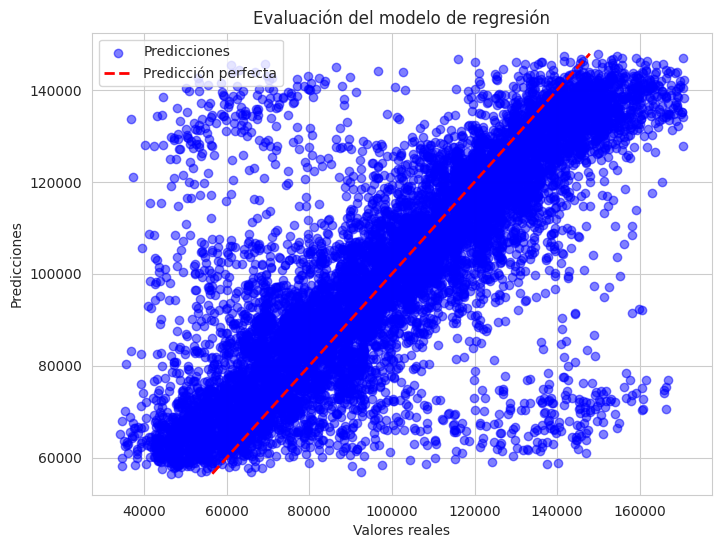

In [14]:
"""
Graficar los resultados de la predicción contra valores reales
"""

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred, color='blue', alpha=0.5, label='Predicciones')
plt.plot([y_test_pred.min(), y_test_pred.max()],
         [y_test_pred.min(), y_test_pred.max()],
         'r--', linewidth=2, label="Predicción perfecta")
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.title('Evaluación del modelo de regresión')
plt.legend()
plt.show()

**Clasificación**: Predecir una categoría o clase. Ejemplo, predecir si un cliente se va o se queda (**churn:** si / no), si un correo es spam o no, si un tumor es beligno o maligno.